# 04 — Analysis (Explore & Interpret)

Ten questions answered from the enriched dataset built in notebooks 01–03.

**Data**: 333 race-editions across the Tour de France (1903–2026), Giro d'Italia (1909–2026)
and Vuelta a España (1935–2025), joined to biographical data for 156 of 161 riders.

**Filtering convention.** Every analysis states which rows it uses:

| Status | Rows | When it counts |
|---|---|---|
| `held` | 302 | Always |
| `disputed` | 7 | Route-level questions only (TdF 1999–2005 were raced; the results were annulled) |
| `no_race` | 23 | Never (no edition took place) |
| `team_only` | 1 | Route-level questions only (1912 Giro had no individual classification) |

This distinction matters: excluding 1999–2005 from a question about race distance would remove
seven editions that genuinely happened.

## Questions

**Rebuilt from the original project (Tour de France only, no Pandas):**
1. Which nationalities have produced the most Grand Tour winners?
2. Which riders have won most often, and when?
3. How have race distances evolved?
4. How do the most successful riders compare?
5. At what age do riders win?
6. Do the three races' distances correlate over time?
7. Has average winning speed converged across the races?
8. Which riders have won more than one different Grand Tour?
9. Is winner age trending upward, and is the trend meaningful?
10. Does each race have distinct eras of national dominance?

In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent
sys.path.append(str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (11, 5)
plt.rcParams["figure.dpi"] = 110

RACE_NAMES = {"tdf": "Tour de France", "giro": "Giro d'Italia", "vuelta": "Vuelta a España"}
RACE_COLOURS = {"tdf": "#F2C300", "giro": "#E8388A", "vuelta": "#C8102E"}

ed = pd.read_csv("../data/processed/editions_enriched.csv", parse_dates=["birth_date"])
riders = pd.read_csv("../data/processed/riders_enriched.csv", parse_dates=["birth_date"])

held = ed[ed["status"] == "held"]
raced = ed[ed["status"].isin(["held", "disputed", "team_only"])]

print(f"editions: {len(ed)}  |  held: {len(held)}  |  raced: {len(raced)}")

editions: 333  |  held: 294  |  raced: 302


## Q1 — Which nationalities have produced the most winners?

The original project answered this by scraping Wikipedia's pre-computed "by nationality"
summary table. Here the counts are derived from the edition-level data instead, which means
they can be broken down per race rather than only in total — and it removes the dependency on
a summary table whose column order differs between the three pages.

race           giro  tdf  vuelta  total
country                                
Italy            68   10       6     84
France            6   36       9     51
Spain             4   12      32     48
Belgium           7   18       8     33
Great Britain     3    6       3     12
Slovenia          2    5       4     11
Switzerland       3    2       5     10
Luxembourg        2    5       0      7
United States     1    3       2      6
Netherlands       1    2       2      5
Denmark           1    3       1      5
Colombia          2    1       2      5


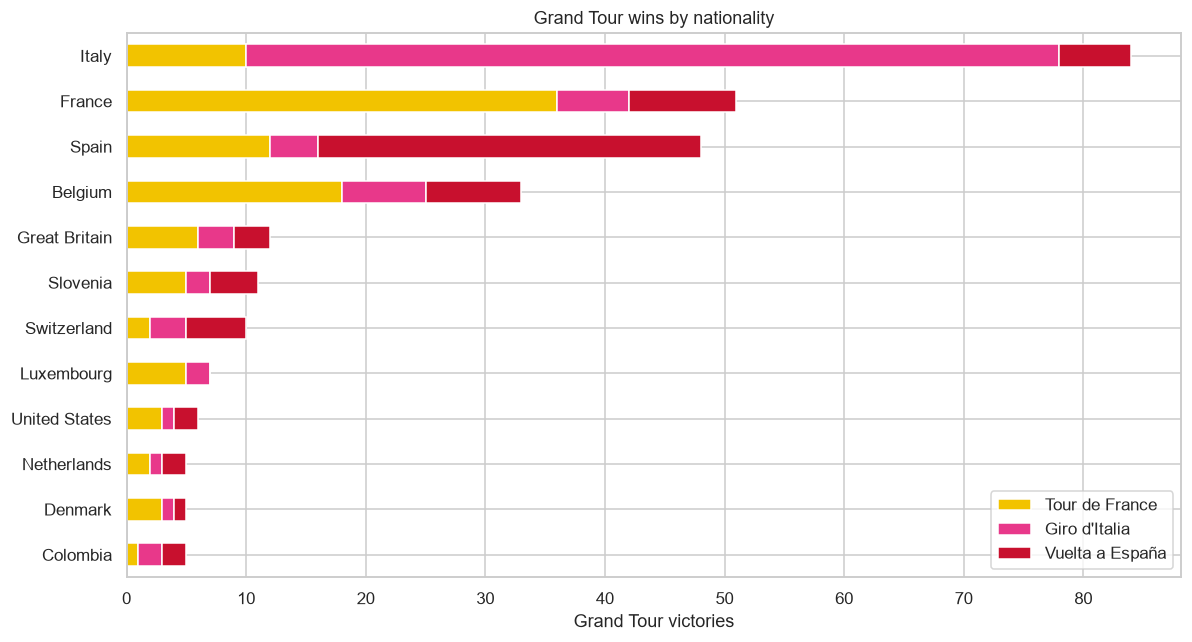

In [2]:
by_country = (held.groupby(["country", "race"]).size()
                  .unstack(fill_value=0)
                  .assign(total=lambda d: d.sum(axis=1))
                  .sort_values("total", ascending=False))

print(by_country.head(12))

top = by_country.head(12).drop(columns="total")
fig, ax = plt.subplots(figsize=(11, 6))
top[["tdf", "giro", "vuelta"]].plot(
    kind="barh", stacked=True, ax=ax,
    color=[RACE_COLOURS[r] for r in ["tdf", "giro", "vuelta"]],
)
ax.invert_yaxis()
ax.set_xlabel("Grand Tour victories")
ax.set_ylabel("")
ax.set_title("Grand Tour wins by nationality")
ax.legend([RACE_NAMES[r] for r in ["tdf", "giro", "vuelta"]], title="")
plt.tight_layout()
plt.show()

### Q1 findings

| Country | Total | TdF | Giro | Vuelta | Home race share |
|---|---|---|---|---|---|
| Italy | 84 | 10 | **68** | 6 | 81% |
| France | 51 | **36** | 6 | 9 | 71% |
| Spain | 48 | 12 | 4 | **32** | 67% |
| Belgium | 33 | 18 | 7 | 8 | — |

**The home-race effect dominates.** Each of the three cycling nations wins overwhelmingly at
home: Italy takes 81% of its Grand Tour victories at the Giro, France 71% at the Tour, Spain
67% at the Vuelta. This is a pattern the original project could not have detected, because
with a single race there is nothing to compare against.

**Belgium is the exception that clarifies the rule.** With 33 wins and no home Grand Tour, its
victories spread 18/7/8 across the three races. Belgian success is not concentrated anywhere,
which suggests the home advantage is about participation and selection — riders target their
national race — rather than about the terrain favouring locals.

**Note on nationality data.** Country here is the flag shown in the results table, which reflects
the licence the rider raced under. Wikidata's citizenship data (collected in notebook 03) is
messier and often multi-valued: pre-1946 Italian riders hold both *Italy* and *Kingdom of Italy*,
Soviet-era riders both *Russia* and *Soviet Union*, and Chris Froome both *Kenya* and
*United Kingdom*. The race-table nationality is the more consistent choice for counting wins.

## Q2 — Which riders have won most often, and when?

The original project answered this for the Tour de France alone, reading from a pre-built
JSON file of multiple winners. Here it comes from the edition data directly, so a rider's
victories can be shown across all three races on one timeline.

In [3]:
top_riders = riders.nlargest(12, "wins_total")[
    ["rider_name", "country", "wins_tdf", "wins_giro", "wins_vuelta", "wins_total", "races_won"]
]
print(top_riders.to_string(index=False))

      rider_name       country  wins_tdf  wins_giro  wins_vuelta  wins_total  races_won
     Eddy Merckx       Belgium         5          5            1          11          3
 Bernard Hinault        France         5          3            2          10          3
Jacques Anquetil        France         5          2            1           8          3
Alberto Contador         Spain         2          2            3           7          3
    Chris Froome Great Britain         4          1            2           7          3
    Fausto Coppi         Italy         2          5            0           7          2
   Tadej Pogačar      Slovenia         5          1            0           6          2
   Alfredo Binda         Italy         0          5            0           5          1
  Felice Gimondi         Italy         1          3            1           5          3
    Gino Bartali         Italy         2          3            0           5          2
 Miguel Induráin         Spain  

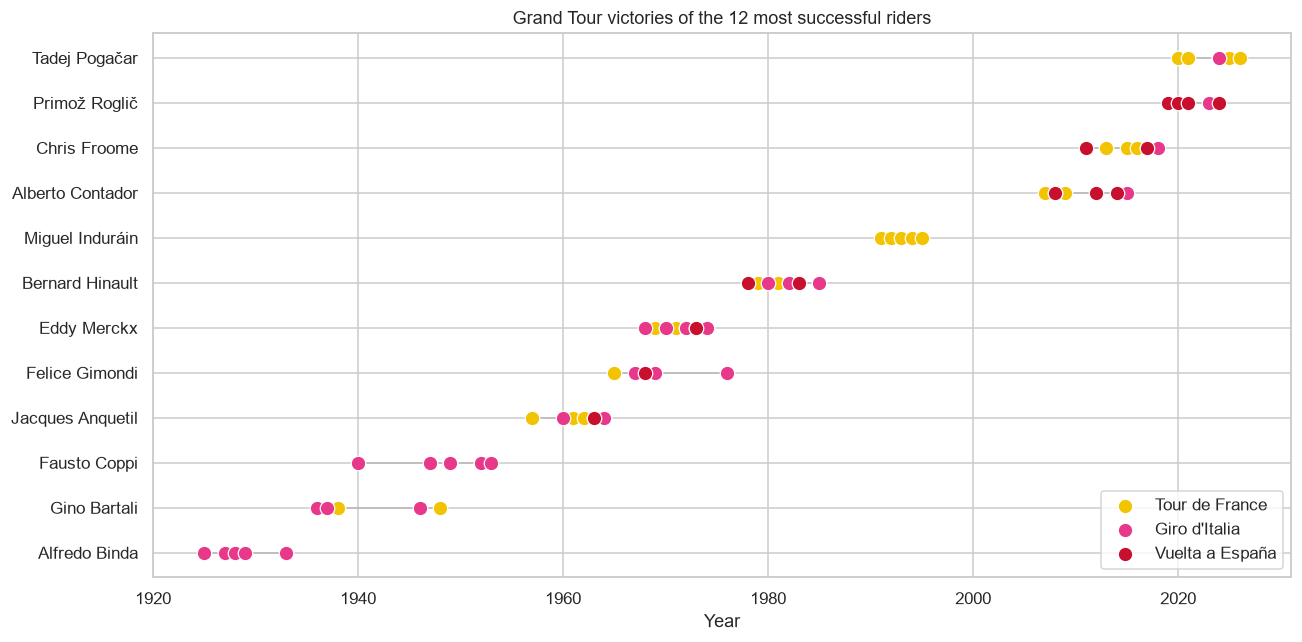

In [4]:
names = top_riders["rider_name"].tolist()
sub = held[held["rider_name"].isin(names)]

# order riders by the year of their first win, so the chart reads chronologically
order = sub.groupby("rider_name")["year"].min().sort_values().index.tolist()
y_pos = {name: i for i, name in enumerate(order)}

fig, ax = plt.subplots(figsize=(12, 6))

for race in ["tdf", "giro", "vuelta"]:
    r = sub[sub["race"] == race]
    ax.scatter(r["year"], [y_pos[n] for n in r["rider_name"]],
               s=90, color=RACE_COLOURS[race], label=RACE_NAMES[race],
               edgecolor="white", linewidth=0.8, zorder=3)

# a faint line spanning each rider's career
for name in order:
    yrs = sub[sub["rider_name"] == name]["year"]
    ax.plot([yrs.min(), yrs.max()], [y_pos[name]] * 2,
            color="grey", alpha=0.35, linewidth=1, zorder=1)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Year")
ax.set_title("Grand Tour victories of the 12 most successful riders")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Q2 findings

| Rider | Country | Total | TdF | Giro | Vuelta | Races won |
|---|---|---|---|---|---|---|
| Eddy Merckx | Belgium | 11 | 5 | 5 | 1 | 3 |
| Bernard Hinault | France | 10 | 5 | 3 | 2 | 3 |
| Jacques Anquetil | France | 8 | 5 | 2 | 1 | 3 |
| Alberto Contador | Spain | 7 | 2 | 2 | 3 | 3 |
| Chris Froome | Great Britain | 7 | 4 | 1 | 2 | 3 |
| Fausto Coppi | Italy | 7 | 2 | 5 | 0 | 2 |

**Merckx leads on total victories with 11**, and is one of only three riders to reach five wins
in two different Grand Tours.

**The timeline shows two distinct shapes of dominance.** Merckx's eleven wins fall inside seven
years (1968–1974); Contador's seven span nine (2007–2015), and Froome's seven span eight. The
earlier riders won more, faster. Whether that reflects deeper modern fields, greater
specialisation, or simply more riders targeting single races is not answerable from this data,
but the compression is visible.

**Specialists versus all-rounders.** Two riders in the top twelve won only one race:
Miguel Induráin (5 Tours, nothing else) and Alfredo Binda (5 Giri, nothing else). Six of the
twelve won all three. The chart's colour composition separates these immediately — Induráin's
row is entirely yellow, Binda's entirely pink, while Hinault's and Contador's alternate.

**Eras are visible as gaps.** No rider in this group has victories spanning 1996–2006, the
decade whose Tour results were later annulled or reassigned. The absence is a consequence of
the data-quality decisions made in notebook 02, not of the sport pausing.

## Q3 — How have race distances evolved?

The original project plotted Tour de France distance against year as a scatter and observed
that it fell. With three races the question becomes sharper: did they all shrink, at the same
time, and by the same amount?

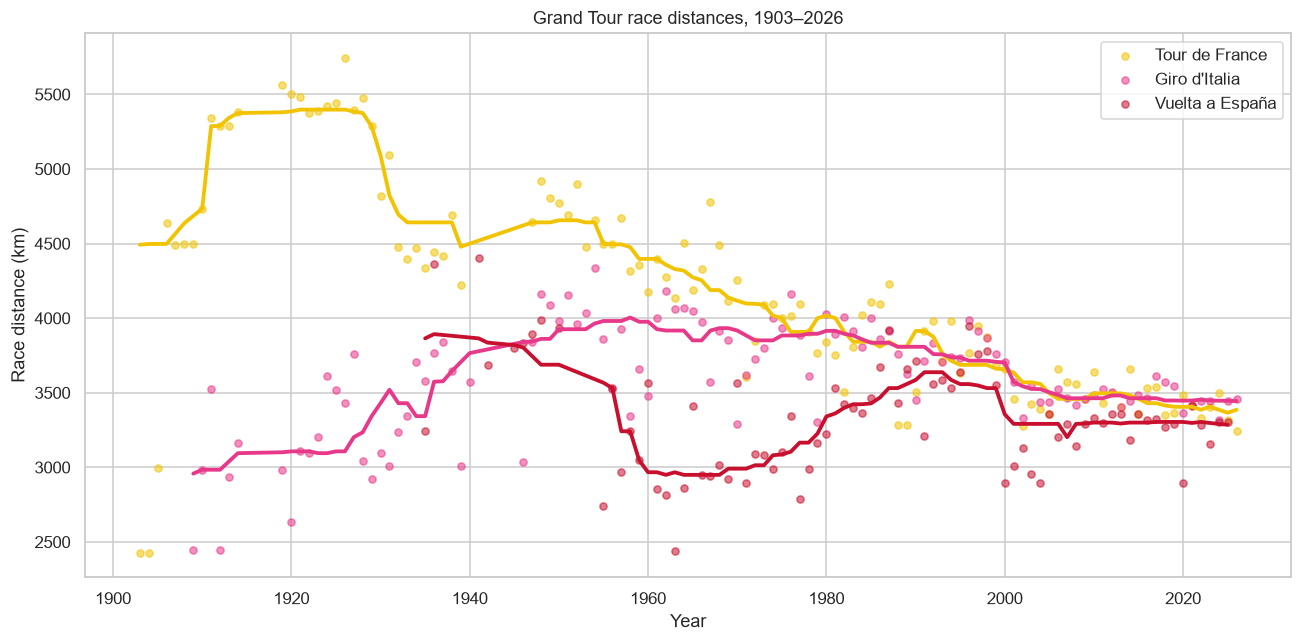

        count    mean    std     min     25%     50%     75%     max
race                                                                
giro    109.0  3590.0  368.0  2443.0  3430.0  3577.0  3868.0  4337.0
tdf     113.0  4159.0  713.0  2428.0  3559.0  4098.0  4637.0  5745.0
vuelta   80.0  3331.0  365.0  2442.0  3073.0  3304.0  3551.0  4406.0


In [5]:
fig, ax = plt.subplots(figsize=(12, 6))

for race in ["tdf", "giro", "vuelta"]:
    sub = raced[(raced["race"] == race) & raced["distance_km"].notna()]
    ax.scatter(sub["year"], sub["distance_km"], s=22, alpha=0.55,
               color=RACE_COLOURS[race], label=RACE_NAMES[race])

    # 30-year rolling median shows the trend without assuming a shape
    smooth = sub.sort_values("year").set_index("year")["distance_km"].rolling(15, center=True, min_periods=5).median()
    ax.plot(smooth.index, smooth.values, color=RACE_COLOURS[race], linewidth=2.5)

ax.set_xlabel("Year")
ax.set_ylabel("Race distance (km)")
ax.set_title("Grand Tour race distances, 1903–2026")
ax.legend()
plt.tight_layout()
plt.show()

print(raced.groupby("race")["distance_km"].describe().round(0))

### Q3 findings

| Race | Editions | Mean | Std | Min | Max |
|---|---|---|---|---|---|
| Tour de France | 113 | 4,159 km | 713 | 2,428 | 5,745 |
| Giro d'Italia | 109 | 3,590 km | 368 | 2,443 | 4,337 |
| Vuelta a España | 80 | 3,331 km | 365 | 2,442 | 4,406 |

**The three races have converged.** They began at very different lengths — the Tour peaked
above 5,700 km in the 1920s while the Giro sat near 3,100 km — and since roughly 2000 all
three have settled into a narrow band around 3,300–3,500 km. The rolling medians, which were
separated by more than 2,000 km in the 1920s, are now within about 200 km of each other.

**The Tour's variability is the story.** Its standard deviation (713 km) is roughly double the
other two (368 and 365). The Tour was the race that changed most: a sharp climb to ~5,400 km
between 1910 and 1926, then a steep drop around 1930, then a long steady decline. The Giro and
Vuelta were never as long and never varied as much.

**Convergence suggests regulation, not coincidence.** Three independently organised races,
in three countries, arriving at nearly the same length is more consistent with a governing
constraint — the UCI caps Grand Tour length and stage distances — than with three organisers
independently reaching the same conclusion.

**What the original project could see, and what it could not.** Plotting the Tour alone shows
a decline and invites the explanation "races got shorter as they got faster." Plotting all
three shows the decline is mostly a *Tour* phenomenon: the Giro fell by roughly 500 km across
its whole history, the Tour by nearly 2,000. A single-race view would have generalised a
pattern that is largely specific to one race.

**Methodological note.** The trend lines are 15-year rolling medians, not fitted regressions.
The Tour's history is clearly not linear — it rises, drops sharply, then declines — so imposing
a straight line would have described none of those phases. Letting the data show its shape
before choosing a model is the right order of operations.

## Q4 — How do the most successful riders compare?

The original project compared the five-time Tour winners by total winning time in minutes.
That comparison has a flaw: winning time measures route length as much as rider performance.
Anquetil's 1957 Tour took longer than Induráin's 1995 Tour largely because it was 800 km longer.

Average speed removes route length from the comparison, and extending to all three races means
riders can be compared across the Grand Tours they actually rode rather than one only.

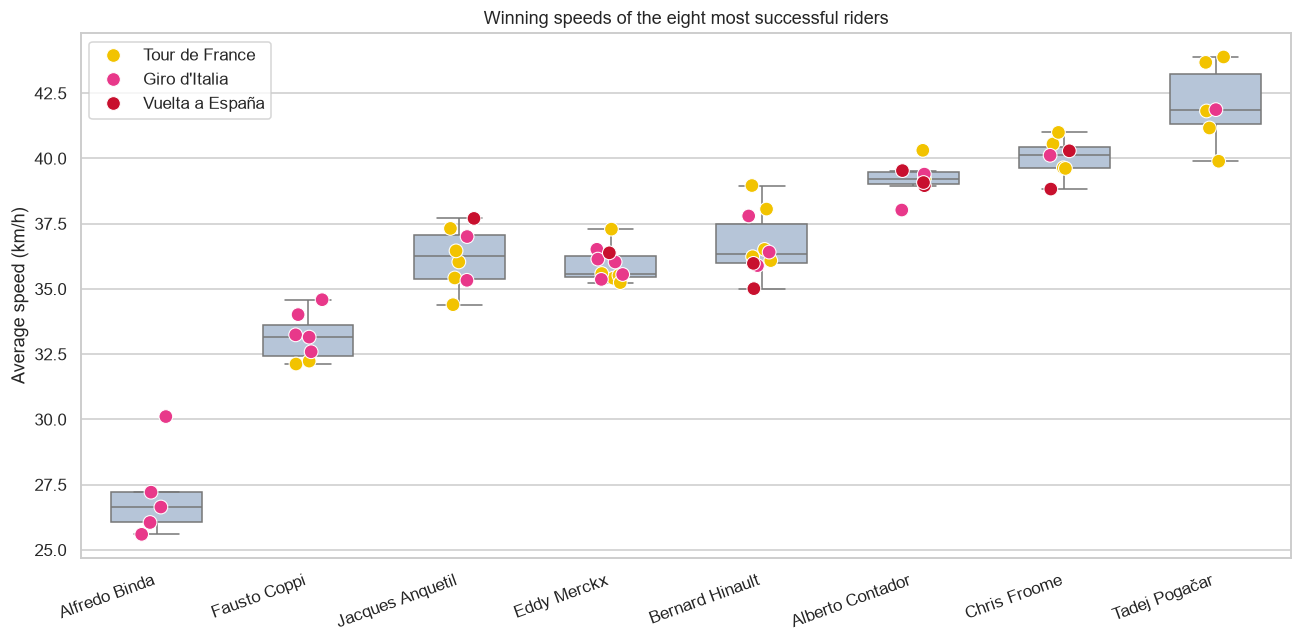

                  count   mean    min    max
rider_name                                  
Alfredo Binda         5  27.12  25.60  30.11
Fausto Coppi          7  33.13  32.12  34.59
Jacques Anquetil      8  36.21  34.40  37.70
Eddy Merckx          11  35.91  35.24  37.29
Bernard Hinault      10  36.69  35.01  38.96
Alberto Contador      7  39.22  38.02  40.31
Chris Froome          7  40.01  38.83  41.00
Tadej Pogačar         6  42.05  39.89  43.89


In [6]:
names = riders.nlargest(8, "wins_total")["rider_name"].tolist()
sub = held[held["rider_name"].isin(names) & held["avg_speed_kmh"].notna()]

order = sub.groupby("rider_name")["year"].min().sort_values().index.tolist()

fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(data=sub, x="rider_name", y="avg_speed_kmh", order=order,
            color="lightsteelblue", width=0.6, ax=ax, showfliers=False)
sns.stripplot(data=sub, x="rider_name", y="avg_speed_kmh", order=order,
              hue="race", palette=RACE_COLOURS, size=9,
              edgecolor="white", linewidth=0.7, ax=ax)

ax.set_xlabel("")
ax.set_ylabel("Average speed (km/h)")
ax.set_title("Winning speeds of the eight most successful riders")
handles, labels = ax.get_legend_handles_labels()
ax.legend(handles, [RACE_NAMES.get(l, l) for l in labels], title="", loc="upper left")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

print(sub.groupby("rider_name")["avg_speed_kmh"]
        .agg(["count", "mean", "min", "max"]).round(2)
        .reindex(order).to_string())

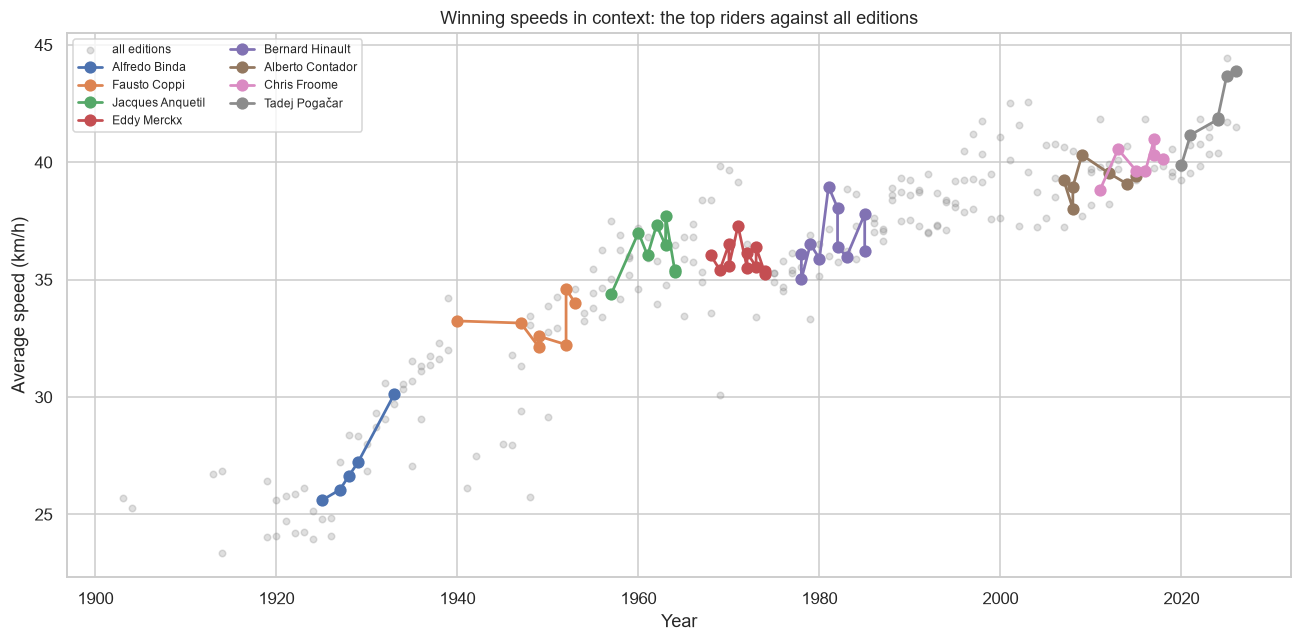

In [7]:
fig, ax = plt.subplots(figsize=(12, 6))

allsp = held[held["avg_speed_kmh"].notna()]
ax.scatter(allsp["year"], allsp["avg_speed_kmh"], s=18, alpha=0.25,
           color="grey", label="all editions")

for name in order:
    r = sub[sub["rider_name"] == name].sort_values("year")
    ax.plot(r["year"], r["avg_speed_kmh"], marker="o", linewidth=1.8,
            markersize=7, label=name)

ax.set_xlabel("Year")
ax.set_ylabel("Average speed (km/h)")
ax.set_title("Winning speeds in context: the top riders against all editions")
ax.legend(fontsize=8, ncol=2)
plt.tight_layout()
plt.show()

### Q4 findings

| Rider | Wins | Mean speed | Range |
|---|---|---|---|
| Alfredo Binda | 5 | 27.12 km/h | 25.60–30.11 |
| Fausto Coppi | 7 | 33.13 | 32.12–34.59 |
| Jacques Anquetil | 8 | 36.21 | 34.40–37.70 |
| Eddy Merckx | 11 | 35.91 | 35.24–37.29 |
| Bernard Hinault | 10 | 36.69 | 35.01–38.96 |
| Alberto Contador | 7 | 39.22 | 38.02–40.31 |
| Chris Froome | 7 | 40.01 | 38.83–41.00 |
| Tadej Pogačar | 6 | 42.05 | 39.89–43.89 |

**Read alone, the first chart says Pogačar is 55% faster than Binda. That conclusion is wrong**,
and the second chart shows why: the ordering is almost perfectly chronological. The riders are
sorted by era, and speed rises monotonically with era. What the boxplot measures is the year
each rider competed, not their ability.

**Against their contemporaries, the picture changes completely.** Plotted over all editions,
every one of these riders sits at or slightly above the cloud of their own era — but none is a
dramatic outlier. Binda's 27 km/h in the late 1920s was at the top of what was possible then;
Pogačar's 42 km/h is at the top of what is possible now. The gap between them is equipment,
road surfaces, nutrition and race design, not physiology.

**Merckx is the interesting case.** His mean (35.91) is *lower* than Anquetil's (36.21) despite
racing a decade later, and his range is the narrowest of any rider here (35.24–37.29, just
2 km/h). Two readings are possible: he won consistently rather than spectacularly, or his 11
wins across all three races included slower editions that riders with fewer wins avoided.
Distinguishing these would need per-edition field data this dataset does not contain.

**The methodological point.** The original project compared five-time Tour winners by total
minutes and concluded Induráin was fastest. That comparison confounds rider speed with route
length. Switching to km/h removes route length — but as the second chart shows, it does not
remove the era effect. **Cross-era comparison of athletes is not possible from results data
alone**, and the honest answer to "who was fastest" is that the question is not well-posed.

## Q5 — At what age do riders win?

The original project computed age as `winning_year − birth_year`, which is off by up to a
year depending on whether the rider's birthday had passed. Here age is computed from the
actual race end date against the full birth date.

The calculation validates against three independently documented records: Henri Cornet
19.97 years at the 1904 Tour (Wikipedia: "just short of his 20th birthday"), Fausto Coppi
20.71 at the 1940 Giro ("20 years, 158 days"), and Firmin Lambot 36.36 at the 1922 Tour
("36 years, 4 months").

Editions with a known age: 288 of 294

count    288.00
mean      27.92
std        3.33
min       19.97
25%       25.58
50%       27.74
75%       30.18
max       41.90
Name: age_at_win, dtype: float64


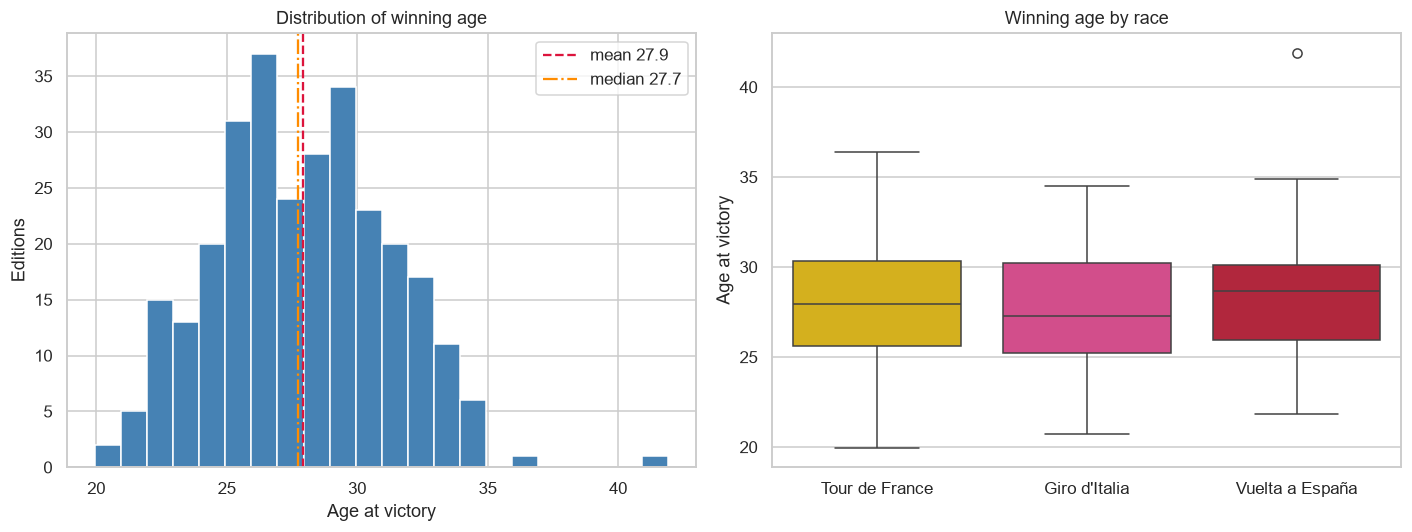


By race:
        count   mean  median   std
race                              
giro      106  27.59   27.28  3.33
tdf       106  27.97   27.93  3.35
vuelta     76  28.31   28.68  3.31


In [9]:
aged = held[held["age_at_win"].notna()]
print(f"Editions with a known age: {len(aged)} of {len(held)}\n")
print(aged["age_at_win"].describe().round(2))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(aged["age_at_win"], bins=22, edgecolor="white", color="steelblue")
axes[0].axvline(aged["age_at_win"].mean(), color="crimson", linestyle="--",
                label=f"mean {aged['age_at_win'].mean():.1f}")
axes[0].axvline(aged["age_at_win"].median(), color="darkorange", linestyle="-.",
                label=f"median {aged['age_at_win'].median():.1f}")
axes[0].set_xlabel("Age at victory")
axes[0].set_ylabel("Editions")
axes[0].set_title("Distribution of winning age")
axes[0].legend()

sns.boxplot(data=aged, x="race", y="age_at_win", ax=axes[1],
            hue="race", palette=RACE_COLOURS, legend=False,
            order=["tdf", "giro", "vuelta"])

axes[1].set_xticks(range(3))
axes[1].set_xticklabels([RACE_NAMES[r] for r in ["tdf", "giro", "vuelta"]])
axes[1].set_xlabel("")
axes[1].set_ylabel("Age at victory")
axes[1].set_title("Winning age by race")

plt.tight_layout()
plt.show()

print("\nBy race:")
print(aged.groupby("race")["age_at_win"].agg(["count", "mean", "median", "std"]).round(2))

### Q5 findings

Winning age is **remarkably stable**: mean 27.9, median 27.7, standard deviation 3.3 years.
Half of all Grand Tour victories come from riders aged 25.6 to 30.2. The distribution is close
to symmetric with a slight right tail — a few late winners, no early ones, which is what a
biological floor on physical maturity would produce.

**The three races are nearly identical:**

| Race | n | Mean | Median | Std |
|---|---|---|---|---|
| Giro d'Italia | 106 | 27.59 | 27.28 | 3.33 |
| Tour de France | 106 | 27.97 | 27.93 | 3.35 |
| Vuelta a España | 76 | 28.31 | 28.68 | 3.31 |

The Vuelta's winners are on average 0.7 years older than the Giro's. That ordering is
plausible — the Vuelta runs in September and has historically been a target for riders whose
season went wrong earlier — but 0.7 years against a standard deviation of 3.3 is a small
difference on a modest sample. It is suggestive, not established. Q9 tests whether age trends
are meaningful using a proper null model.

**The extremes are the interesting part.** Chris Horner won the 2013 Vuelta at 41.9, more than
five years older than any other Grand Tour winner and clearly separated as an outlier on the
boxplot. At the other end, Henri Cornet (19.97, 1904 Tour) and Fausto Coppi (20.71, 1940 Giro)
are the only winners under 21.

**Coverage**: 288 of 294 held editions have a computable age. The six gaps are riders whose
Wikidata match failed (documented in notebook 03).

## Q6 — Do the three races' distances correlate over time?

Q3 showed the races converged in length. This asks a different question: do they move
*together* year to year? Convergence over a century and year-on-year co-movement are separate
claims, and the second does not follow from the first.

Years with all three races: 76  (1935–2025)

Raw distance correlation:
race     giro    tdf  vuelta
race                        
giro    1.000  0.565   0.046
tdf     0.565  1.000   0.056
vuelta  0.046  0.056   1.000 

Year-on-year change correlation:
race     giro    tdf  vuelta
race                        
giro    1.000  0.160  -0.196
tdf     0.160  1.000   0.066
vuelta -0.196  0.066   1.000


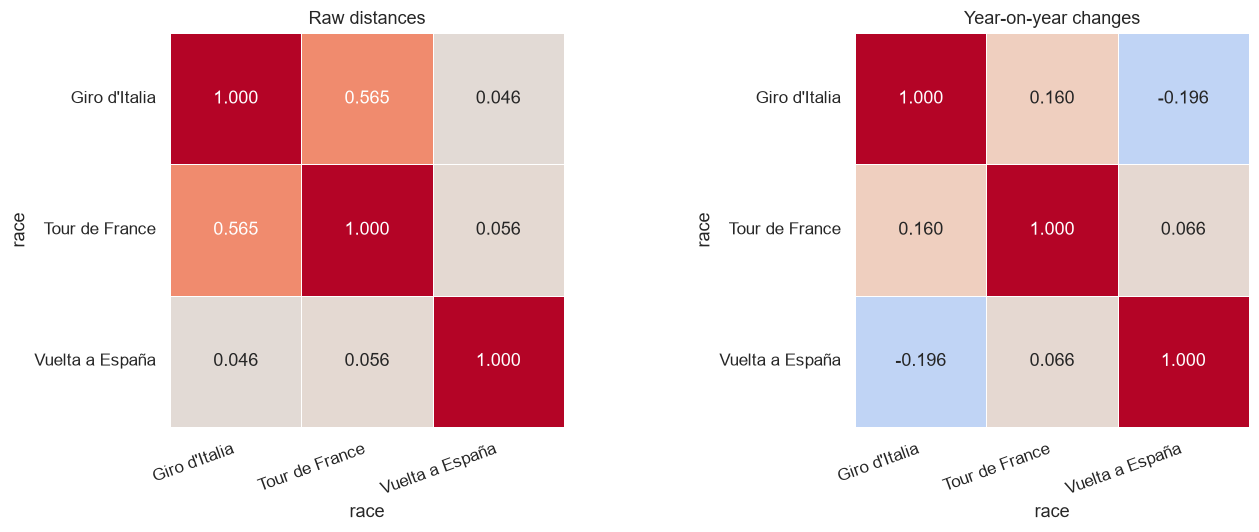

In [10]:
wide = (raced[raced["distance_km"].notna()]
        .pivot_table(index="year", columns="race", values="distance_km", aggfunc="first"))

overlap = wide.dropna()
print(f"Years with all three races: {len(overlap)}  ({overlap.index.min()}–{overlap.index.max()})\n")

print("Raw distance correlation:")
print(overlap.corr().round(3), "\n")

changes = overlap.diff().dropna()
print("Year-on-year change correlation:")
print(changes.corr().round(3))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (data, title) in zip(axes, [(overlap.corr(), "Raw distances"),
                                    (changes.corr(), "Year-on-year changes")]):
    sns.heatmap(data, annot=True, fmt=".3f", cmap="coolwarm", center=0,
                vmin=-1, vmax=1, square=True, linewidths=0.5, ax=ax, cbar=False)
    ax.set_title(title)
    ax.set_xticklabels([RACE_NAMES[t.get_text()] for t in ax.get_xticklabels()], rotation=20, ha="right")
    ax.set_yticklabels([RACE_NAMES[t.get_text()] for t in ax.get_yticklabels()], rotation=0)
plt.tight_layout()
plt.show()

### Q6 findings

**Raw distances** (76 years where all three races were held, 1935–2025):

| Pair | r |
|---|---|
| Giro ↔ Tour | **0.565** |
| Giro ↔ Vuelta | 0.046 |
| Tour ↔ Vuelta | 0.056 |

**Year-on-year changes:**

| Pair | r |
|---|---|
| Giro ↔ Tour | 0.160 |
| Giro ↔ Vuelta | −0.196 |
| Tour ↔ Vuelta | 0.066 |

**The Giro and Tour share a trend; the Vuelta does not.** The moderate raw correlation between
Giro and Tour (0.565) reflects a common century-long decline in length. The Vuelta correlates
with neither (0.046, 0.056) — its distances moved on their own schedule. Looking back at the Q3
chart explains why: the Vuelta fell sharply through the 1950s to around 3,000 km, then *rose*
again through the 1970s–80s while the Tour was still falling. Two races declining and one
oscillating produces exactly this pattern.

**Year to year, nothing moves together.** After differencing, all three coefficients fall below
0.2 in absolute value. The Giro–Tour correlation collapses from 0.565 to 0.160, which confirms
that the raw figure was a shared time trend rather than a relationship between the races. There
is no evidence that organisers respond to each other's route decisions within a season.

**Why differencing matters.** Two variables that both decline over a century will correlate
strongly whether or not they have anything to do with each other — a textbook spurious
correlation. Correlating the *changes* removes the shared trend and asks the question actually
of interest: when one race got longer, did the others? The answer is no.

**Conclusion.** The convergence found in Q3 is a slow, independent drift toward a common
constraint — most plausibly UCI regulation on Grand Tour length — rather than coordination
between organisers. The three races arrived at similar distances by separate routes.

## Q7 — Has average winning speed converged across the races?

Distances converged. Speed is the other half of the picture, and it is the more direct measure
of how the sport itself changed: faster racing reflects equipment, road surfaces, nutrition and
tactics rather than route design.

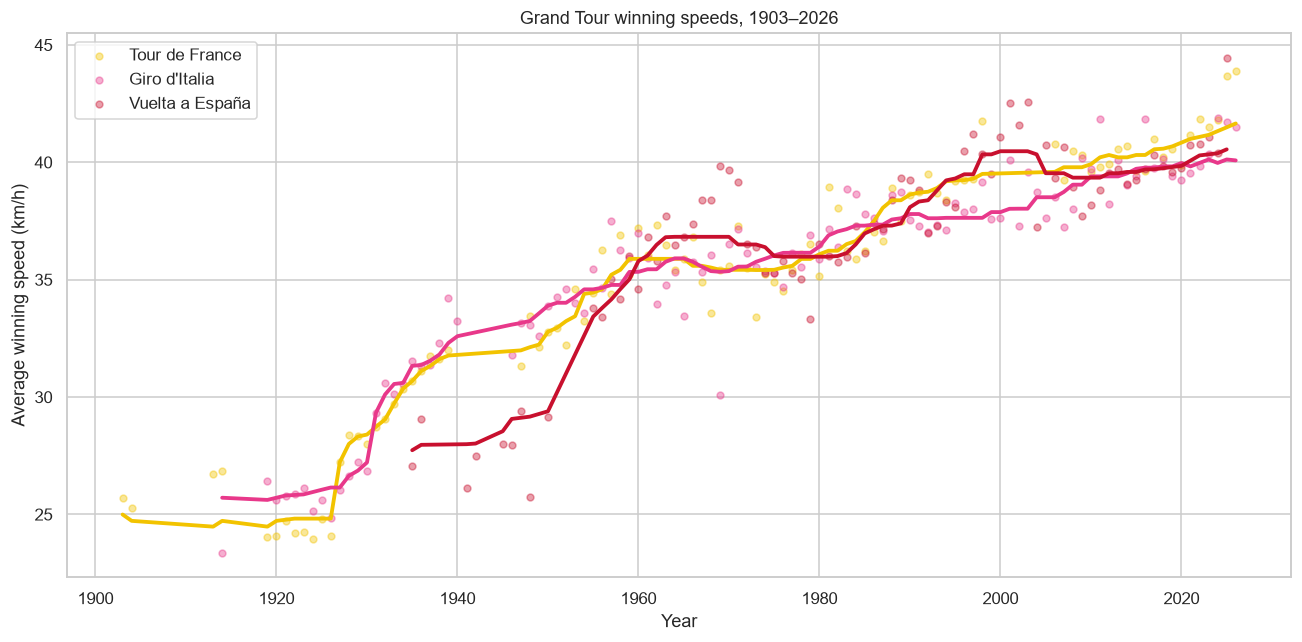

In [11]:
speeds = held[held["avg_speed_kmh"].notna()]

fig, ax = plt.subplots(figsize=(12, 6))
for race in ["tdf", "giro", "vuelta"]:
    sub = speeds[speeds["race"] == race].sort_values("year")
    ax.scatter(sub["year"], sub["avg_speed_kmh"], s=20, alpha=0.4,
               color=RACE_COLOURS[race], label=RACE_NAMES[race])
    smooth = sub.set_index("year")["avg_speed_kmh"].rolling(15, center=True, min_periods=5).median()
    ax.plot(smooth.index, smooth.values, color=RACE_COLOURS[race], linewidth=2.5)

ax.set_xlabel("Year")
ax.set_ylabel("Average winning speed (km/h)")
ax.set_title("Grand Tour winning speeds, 1903–2026")
ax.legend()
plt.tight_layout()
plt.show()

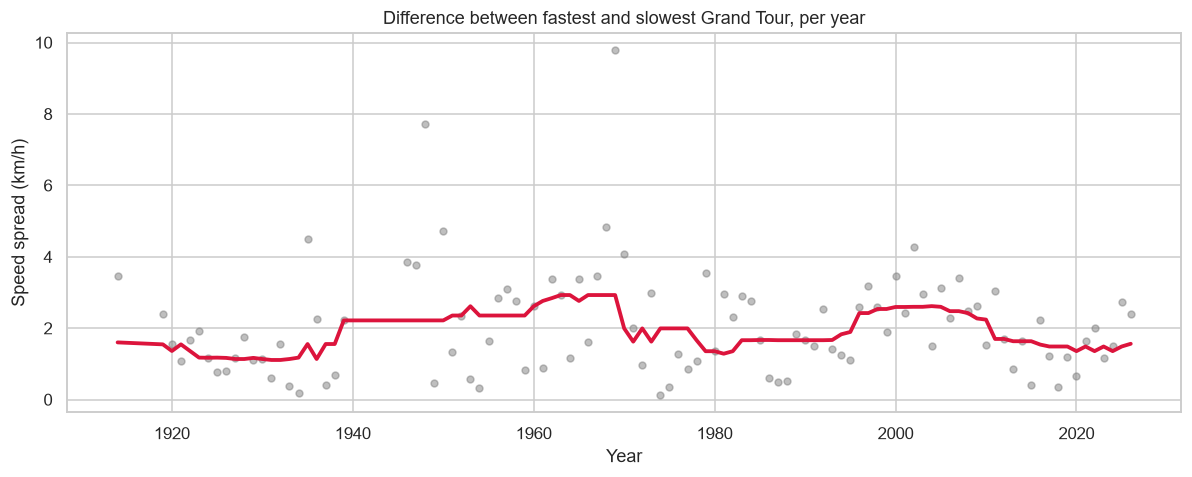

1935-1970: mean spread 2.81 km/h  (n=30)
1971-2000: mean spread 1.79 km/h  (n=30)
2001-2026: mean spread 1.97 km/h  (n=26)


In [12]:
speeds_wide = speeds.pivot_table(index="year", columns="race", values="avg_speed_kmh", aggfunc="first")

# spread between fastest and slowest race, per year, where at least two ran
spread = speeds_wide.max(axis=1) - speeds_wide.min(axis=1)
spread = spread[speeds_wide.notna().sum(axis=1) >= 2]

fig, ax = plt.subplots(figsize=(11, 4.5))
ax.scatter(spread.index, spread.values, s=20, alpha=0.5, color="grey")
ax.plot(spread.rolling(15, center=True, min_periods=5).median(), color="crimson", linewidth=2.5)
ax.set_xlabel("Year")
ax.set_ylabel("Speed spread (km/h)")
ax.set_title("Difference between fastest and slowest Grand Tour, per year")
plt.tight_layout()
plt.show()

for label, window in [("1935-1970", (1935, 1970)), ("1971-2000", (1971, 2000)), ("2001-2026", (2001, 2026))]:
    s = spread[(spread.index >= window[0]) & (spread.index <= window[1])]
    print(f"{label}: mean spread {s.mean():.2f} km/h  (n={len(s)})")

### Q7 findings

**Speed roughly doubled**, from around 25 km/h in the 1900s–20s to over 42 km/h today. The
sharpest gains came between 1925 and 1960; progress since 1980 has been much flatter.

**Convergence in speed, but not the way distance converged:**

| Era | Mean spread between fastest and slowest race |
|---|---|
| 1935–1970 | 2.81 km/h |
| 1971–2000 | 1.79 km/h |
| 2001–2026 | 1.97 km/h |

The gap narrowed sharply after 1970 and has since **stabilised rather than continued shrinking**.
The three races are now consistently within about 2 km/h of one another, and have been for
fifty years. This is a different pattern from distance, which converged steadily and is still
converging.

**The Vuelta's late start is visible.** From its 1935 debut until the mid-1950s it was the
slowest of the three by a wide margin — around 28 km/h when the Tour and Giro were already
above 32. It closed that gap through the 1950s and has since tracked the others closely. Being
established 32 years after the Tour, in a country with less developed cycling infrastructure,
is the plausible explanation.

**Progress has slowed.** Between 1925 and 1960 speeds rose roughly 10 km/h in 35 years. Between
1990 and 2026, roughly 3 km/h in 36 years. Whether this reflects approaching physiological
limits, route design deliberately preserving difficulty, or better doping controls in the
modern era is not answerable from this data — all three are consistent with the curve.

**A caveat on the 1968 outlier.** One year shows a spread near 10 km/h. Single-year extremes
in this measure are driven by route design (a mountainous edition against a flat one), not by
rider quality, which is why the rolling median rather than individual points carries the
interpretation.

## Q8 — Which riders have won more than one different Grand Tour?

This question is impossible to ask with single-race data, and it was the main motivation for
expanding the project's scope. Winning all three Grand Tours is one of cycling's rarest
achievements.

The result also serves as a validation check: Wikipedia states that eight riders have completed
the set. Any other number means the pipeline has a bug.

In [13]:
multi = riders[riders["races_won"] >= 2].sort_values(
    ["races_won", "wins_total"], ascending=False)

print(f"Riders winning 2+ different Grand Tours: {len(multi)}")
print(f"Riders winning all three: {(riders['races_won'] == 3).sum()}\n")

print("All three Grand Tours:")
print(multi[multi["races_won"] == 3][
    ["rider_name", "country", "wins_tdf", "wins_giro", "wins_vuelta", "wins_total"]
].to_string(index=False))

Riders winning 2+ different Grand Tours: 30
Riders winning all three: 8

All three Grand Tours:
      rider_name       country  wins_tdf  wins_giro  wins_vuelta  wins_total
     Eddy Merckx       Belgium         5          5            1          11
 Bernard Hinault        France         5          3            2          10
Jacques Anquetil        France         5          2            1           8
Alberto Contador         Spain         2          2            3           7
    Chris Froome Great Britain         4          1            2           7
  Felice Gimondi         Italy         1          3            1           5
Jonas Vingegaard       Denmark         2          1            1           4
 Vincenzo Nibali         Italy         1          2            1           4


race              giro   tdf  vuelta  completed
rider_name                                     
Jacques Anquetil  1960  1957    1963       1963
Felice Gimondi    1967  1965    1968       1968
Eddy Merckx       1968  1969    1973       1973
Bernard Hinault   1980  1978    1978       1980
Alberto Contador  2008  2007    2008       2008
Vincenzo Nibali   2013  2014    2010       2014
Chris Froome      2018  2013    2011       2018
Jonas Vingegaard  2026  2022    2025       2026


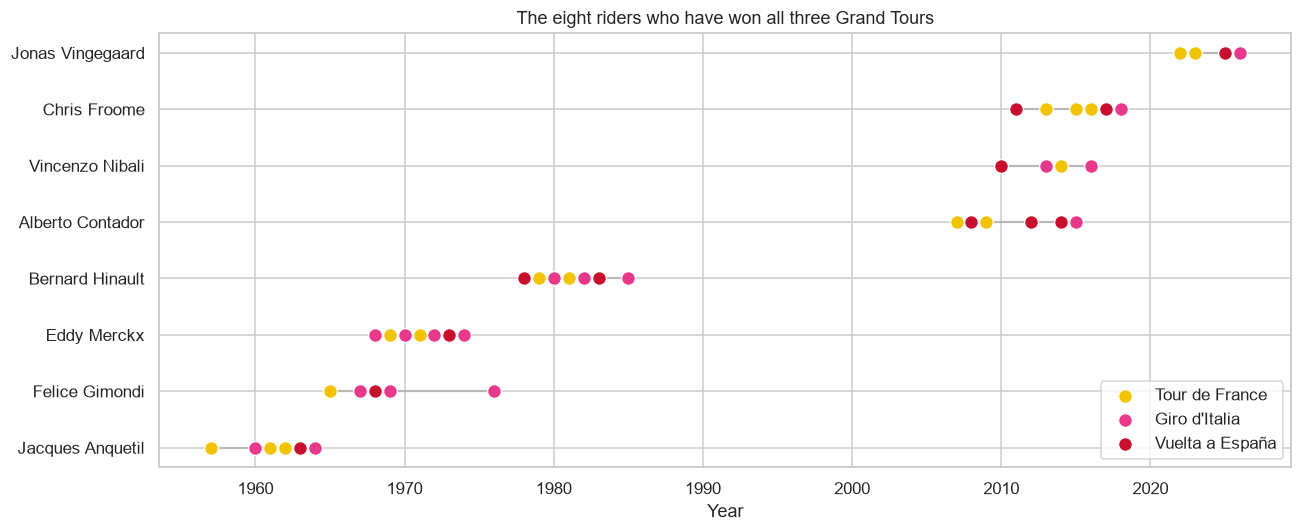

In [14]:
three = riders[riders["races_won"] == 3]["rider_name"].tolist()
sub = held[held["rider_name"].isin(three)]

# the year each rider completed all three
completion = (sub.groupby(["rider_name", "race"])["year"].min()
                 .unstack()
                 .assign(completed=lambda d: d.max(axis=1))
                 .sort_values("completed"))
print(completion.astype("Int64").to_string())

fig, ax = plt.subplots(figsize=(12, 5))
order = completion.index.tolist()
y_pos = {n: i for i, n in enumerate(order)}

for race in ["tdf", "giro", "vuelta"]:
    r = sub[sub["race"] == race]
    ax.scatter(r["year"], [y_pos[n] for n in r["rider_name"]], s=80,
               color=RACE_COLOURS[race], label=RACE_NAMES[race],
               edgecolor="white", linewidth=0.8, zorder=3)

for n in order:
    yrs = sub[sub["rider_name"] == n]["year"]
    ax.plot([yrs.min(), yrs.max()], [y_pos[n]] * 2, color="grey", alpha=0.35, zorder=1)

ax.set_yticks(range(len(order)))
ax.set_yticklabels(order)
ax.set_xlabel("Year")
ax.set_title("The eight riders who have won all three Grand Tours")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

### Q8 findings

**30 riders have won two or more different Grand Tours. Eight have won all three** — matching
Wikipedia's stated figure exactly, which validates the whole pipeline against an independent
source.

| Rider | Country | TdF | Giro | Vuelta | Total | Set completed |
|---|---|---|---|---|---|---|
| Jacques Anquetil | France | 5 | 2 | 1 | 8 | 1963 |
| Felice Gimondi | Italy | 1 | 3 | 1 | 5 | 1968 |
| Eddy Merckx | Belgium | 5 | 5 | 1 | 11 | 1973 |
| Bernard Hinault | France | 5 | 3 | 2 | 10 | 1980 |
| Alberto Contador | Spain | 2 | 2 | 3 | 7 | 2008 |
| Vincenzo Nibali | Italy | 1 | 2 | 1 | 4 | 2014 |
| Chris Froome | Great Britain | 4 | 1 | 2 | 7 | 2018 |
| Jonas Vingegaard | Denmark | 2 | 1 | 1 | 4 | 2026 |

**The achievement comes in two distinct clusters, separated by 28 years.** Four riders completed
the set between 1963 and 1980; then nothing until Contador in 2008; then four more between 2008
and 2026. No rider completed all three in the entire span from 1981 to 2007.

That gap is unlikely to be coincidence. It covers the era of extreme specialisation, when riders
increasingly targeted a single Grand Tour and built their whole season around it — Induráin
(5 Tours, no other Grand Tour) and Armstrong's stripped run are the emblematic cases. The
modern cluster suggests the sport has partly returned to riders contesting multiple Grand Tours.

**The Vuelta is the usual last piece.** For five of the eight riders — Anquetil, Gimondi,
Merckx, Nibali, Vingegaard — one of the two non-Vuelta races came first and the Vuelta completed
or nearly completed the set. This fits its September date and its historical role as the race
riders enter after the season's main objectives.

**Winning all three does not require winning many.** Nibali and Vingegaard completed the set
with four Grand Tour wins each, while Induráin's five wins and Binda's five are all in one race.
Breadth and volume are separate achievements, and the `races_won` column separates them cleanly —
something the original single-race dataset could not express at all.

## Q9 — Is winner age trending upward, and is the trend meaningful?

The original project plotted winner age against year and observed that the points looked
scattered with perhaps a recent upward drift. It stopped at the observation.

This asks the harder question: is there a trend, how large is it, and is it distinguishable
from noise? Eyeballing a scatter is not enough — with 288 points and a spread of 3.3 years,
a slight visual slope can easily be nothing.

Fitted slope : +0.0195 years of age per calendar year
Over a century: +1.95 years
Correlation r : +0.195   (r² = 0.038)


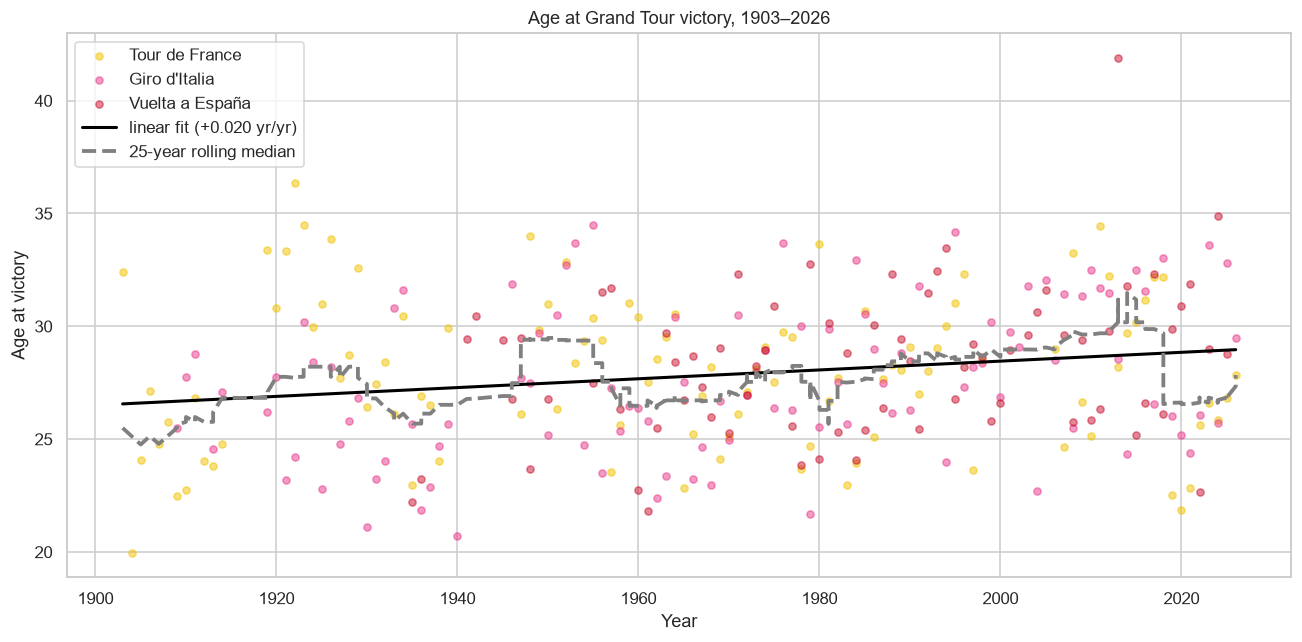

In [15]:
aged = held[held["age_at_win"].notna()].sort_values("year")
x = aged["year"].to_numpy(dtype=float)
y = aged["age_at_win"].to_numpy()

slope, intercept = np.polyfit(x, y, 1)
r = np.corrcoef(x, y)[0, 1]

print(f"Fitted slope : {slope:+.4f} years of age per calendar year")
print(f"Over a century: {slope * 100:+.2f} years")
print(f"Correlation r : {r:+.3f}   (r² = {r**2:.3f})")

fig, ax = plt.subplots(figsize=(12, 6))
for race in ["tdf", "giro", "vuelta"]:
    s = aged[aged["race"] == race]
    ax.scatter(s["year"], s["age_at_win"], s=22, alpha=0.5,
               color=RACE_COLOURS[race], label=RACE_NAMES[race])

xs = np.array([x.min(), x.max()])
ax.plot(xs, slope * xs + intercept, color="black", linewidth=2,
        label=f"linear fit ({slope:+.3f} yr/yr)")
ax.plot(aged.set_index("year")["age_at_win"].rolling(25, center=True, min_periods=8).median(),
        color="grey", linewidth=2.5, linestyle="--", label="25-year rolling median")

ax.set_xlabel("Year")
ax.set_ylabel("Age at victory")
ax.set_title("Age at Grand Tour victory, 1903–2026")
ax.legend()
plt.tight_layout()
plt.show()

Observed |slope|        : 0.0195
Mean |slope| if shuffled: 0.0048
95th percentile         : 0.0118
p-value                 : 0.0008


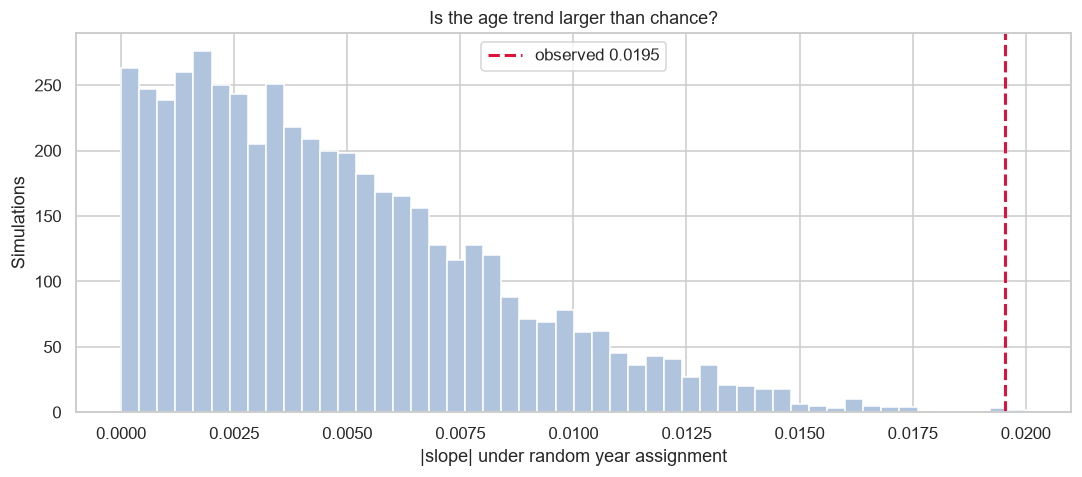

In [16]:
rng = np.random.default_rng(42)

observed = abs(slope)
sim = []
for _ in range(5000):
    shuffled = rng.permutation(y)
    sim.append(abs(np.polyfit(x, shuffled, 1)[0]))
sim = np.array(sim)

p = (sim >= observed).mean()
print(f"Observed |slope|        : {observed:.4f}")
print(f"Mean |slope| if shuffled: {sim.mean():.4f}")
print(f"95th percentile         : {np.percentile(sim, 95):.4f}")
print(f"p-value                 : {p:.4f}")

fig, ax = plt.subplots(figsize=(10, 4.5))
ax.hist(sim, bins=50, edgecolor="white", color="lightsteelblue")
ax.axvline(observed, color="crimson", linestyle="--", linewidth=2,
           label=f"observed {observed:.4f}")
ax.set_xlabel("|slope| under random year assignment")
ax.set_ylabel("Simulations")
ax.set_title("Is the age trend larger than chance?")
ax.legend()
plt.tight_layout()
plt.show()

### Q9 findings

| Quantity | Value |
|---|---|
| Fitted slope | +0.0195 years of age per calendar year |
| Effect over a century | **+1.95 years** |
| Correlation | r = +0.195, r² = 0.038 |
| Mean \|slope\| under shuffled years | 0.0048 |
| 95th percentile under shuffling | 0.0118 |
| **p-value** | **0.0008** |

**The trend is real.** Only 4 of 5,000 random shufflings produced a slope as steep as the
observed one. Winners really are getting older — by about two years across the sport's history,
from roughly 26.5 in 1903 to 29 in 2026.

**The trend is also small.** r² = 0.038 means the year of the race explains under 4% of the
variation in winner age. The other 96% is individual: who happened to be at their peak, who
targeted which race, who crashed out. Both statements are true simultaneously, and reporting
only one would misrepresent the result.

**Statistically significant is not the same as large.** With 288 observations, a genuine but
tiny effect becomes detectable. A two-year shift over 123 years is real, and it is also small
enough that it tells you almost nothing about any individual edition. The permutation test
answers "is this more than chance?" — not "is this important?"

**Why a permutation test rather than a t-test on the slope.** It makes no assumption about the
distribution of residuals. It simply breaks the year–age link by shuffling, recomputes the
slope 5,000 times, and asks how often chance alone produces something this steep. The logic is
transparent enough to defend without invoking distributional theory.

**What the rolling median adds.** The linear fit rises steadily, but the 25-year median shows
the increase is not uniform: broadly flat from 1930 to 1970, rising through the 1980s–2000s,
and notably volatile after 2010, where a spike above 31 (driven partly by Horner's outlier win
at 41.9) is followed by a fall back toward 27 as Pogačar, Bernal and Vingegaard won young. The
straight line describes the century; it does not describe the last decade.

**Against the original project.** The original plotted this scatter and concluded there was "no
fixed winning age but a range of champion profiles" — a fair reading of the picture, but one
that neither measured the trend nor tested it. The trend exists, is measurable, and is small.

## Q10 — Does each race have distinct eras of national dominance?

Q1 showed each race is dominated by its host nation overall. This asks whether that dominance
is constant or whether it comes in waves — and whether the waves differ between races.

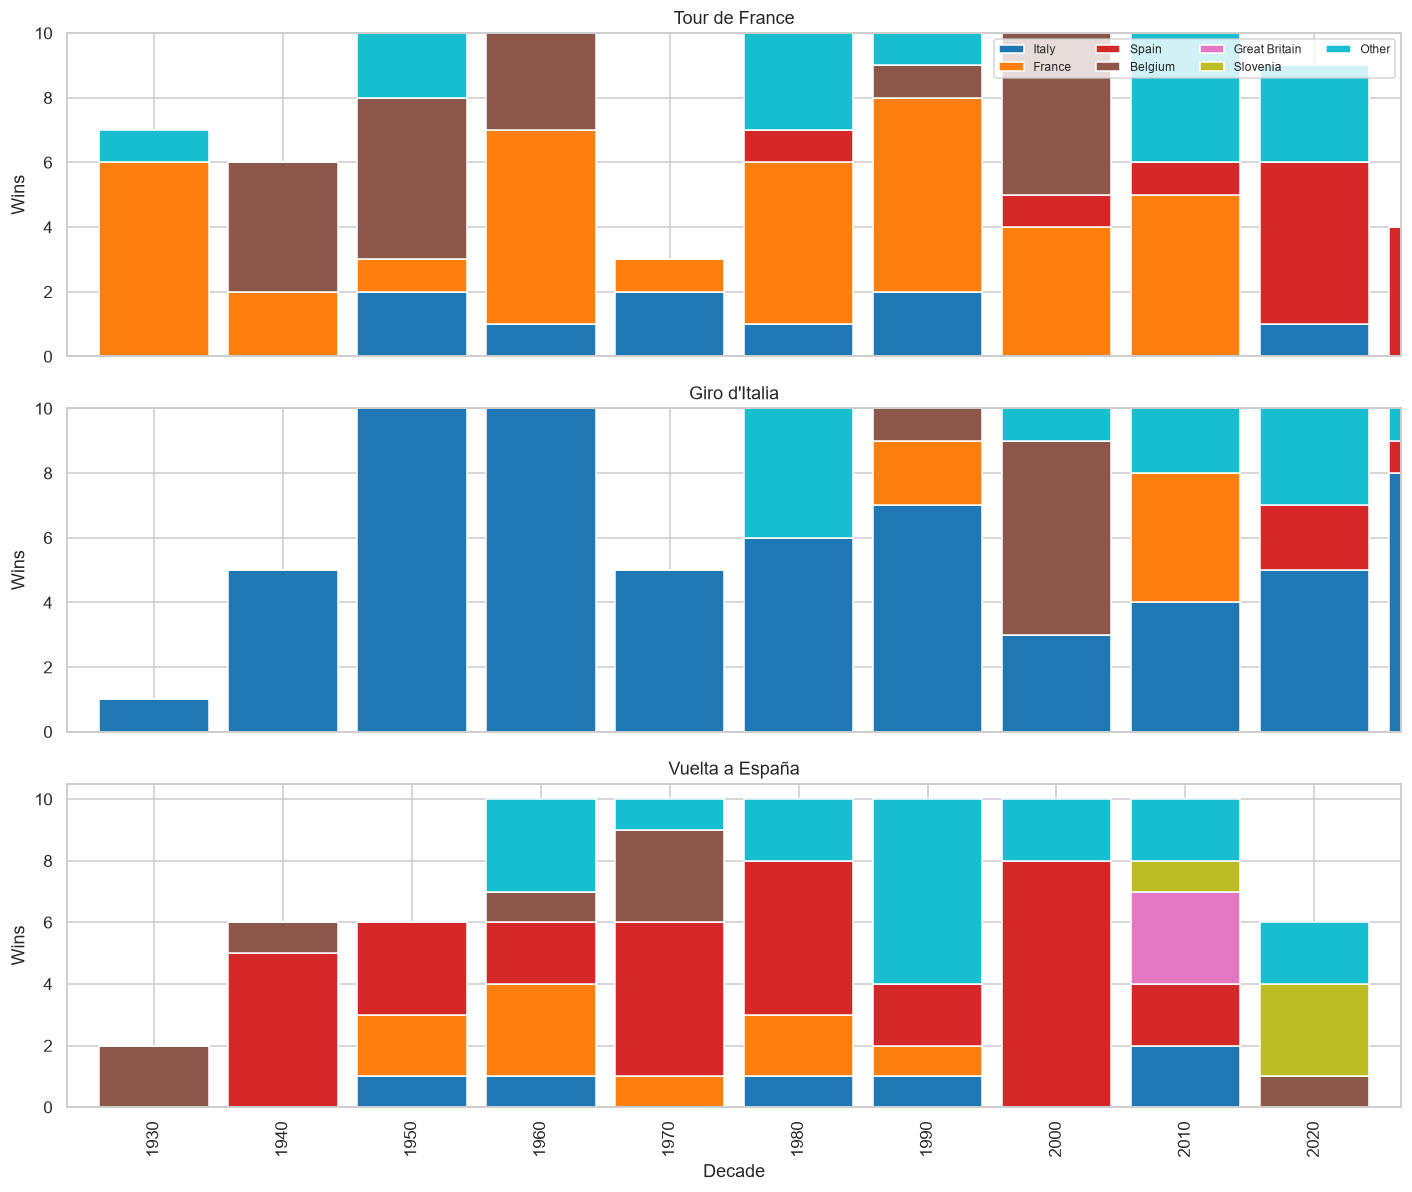

In [17]:
decade = held.assign(decade=(held["year"] // 10) * 10)

top_countries = held["country"].value_counts().head(6).index.tolist()

fig, axes = plt.subplots(3, 1, figsize=(13, 11), sharex=True)

for ax, race in zip(axes, ["tdf", "giro", "vuelta"]):
    d = decade[decade["race"] == race]
    counts = (d.groupby(["decade", "country"]).size().unstack(fill_value=0)
                .reindex(columns=top_countries, fill_value=0))
    others = d.groupby("decade").size() - counts.sum(axis=1)
    counts["Other"] = others

    counts.plot(kind="bar", stacked=True, ax=ax, width=0.85,
                colormap="tab10", legend=(race == "tdf"))
    ax.set_title(RACE_NAMES[race])
    ax.set_ylabel("Wins")
    ax.set_xlabel("")
    if race == "tdf":
        ax.legend(fontsize=8, ncol=4, loc="upper right")

axes[-1].set_xlabel("Decade")
plt.tight_layout()
plt.show()

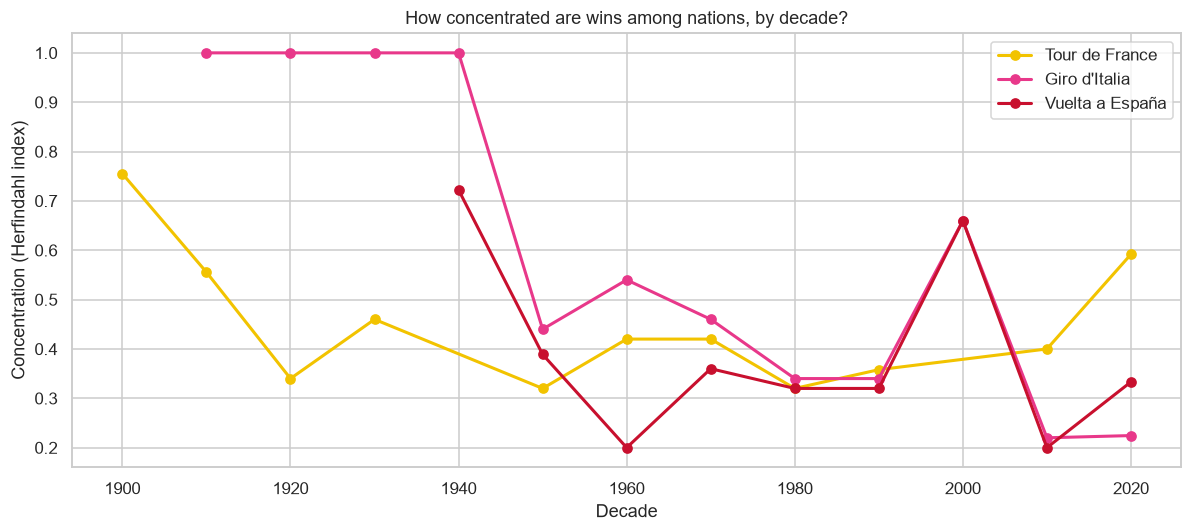

race     giro    tdf  vuelta
decade                      
1900      NaN  0.755     NaN
1910    1.000  0.556     NaN
1920    1.000  0.340     NaN
1930    1.000  0.460     NaN
1940    1.000    NaN   0.722
1950    0.440  0.320   0.389
1960    0.540  0.420   0.200
1970    0.460  0.420   0.360
1980    0.340  0.320   0.320
1990    0.340  0.358   0.320
2000    0.660    NaN   0.660
2010    0.220  0.400   0.200
2020    0.224  0.592   0.333


In [18]:
def hhi(series):
    """Herfindahl index: 1.0 = one nation wins everything, ~0 = perfectly spread."""
    shares = series.value_counts(normalize=True)
    return (shares ** 2).sum()

conc = (decade.groupby(["race", "decade"])["country"]
              .agg(wins="size", concentration=hhi)
              .reset_index())
conc = conc[conc["wins"] >= 5]

fig, ax = plt.subplots(figsize=(11, 5))
for race in ["tdf", "giro", "vuelta"]:
    s = conc[conc["race"] == race]
    ax.plot(s["decade"], s["concentration"], marker="o",
            color=RACE_COLOURS[race], label=RACE_NAMES[race], linewidth=2)

ax.set_xlabel("Decade")
ax.set_ylabel("Concentration (Herfindahl index)")
ax.set_title("How concentrated are wins among nations, by decade?")
ax.legend()
plt.tight_layout()
plt.show()

print(conc.pivot(index="decade", columns="race", values="concentration").round(3).to_string())

### Q10 findings

**Concentration by decade** (Herfindahl index: 1.0 = one nation wins every edition, lower = more spread):

| Decade | TdF | Giro | Vuelta |
|---|---|---|---|
| 1910s–1930s | 0.34–0.56 | **1.000** | — |
| 1950s | 0.320 | 0.440 | 0.389 |
| 1980s | 0.320 | 0.340 | 0.320 |
| 2000s | — | 0.660 | 0.660 |
| 2010s | 0.400 | 0.220 | 0.200 |
| 2020s | 0.592 | 0.224 | 0.333 |

**The Giro was a closed race for four decades.** Its index sits at exactly **1.000** from the
1910s through the 1940s — every single winner Italian, without exception, for forty years. No
other race approaches this. The Tour was already international by the 1920s (index 0.34), and
the Vuelta opened up within two decades of its founding.

**All three converged on openness by the 1980s.** By then every race sits near 0.32–0.34 —
remarkably similar, and reached from very different starting points. This is a second kind of
convergence, alongside distance (Q3) and speed (Q7).

**The three races have since diverged again, in opposite directions.** In the 2010s the Giro
and Vuelta became the most open they have ever been (0.22, 0.20), while the Tour tightened
(0.40, then 0.59 in the 2020s). Pogačar and Vingegaard between them account for most recent
Tours, concentrating wins in Slovenia and Denmark. The most prestigious race is currently the
least nationally diverse — the reverse of the historical pattern.

**A gap worth naming.** The 2000s Tour has no value because seven of its ten editions were
annulled, leaving too few results to compute a meaningful index. The blank is a consequence of
the `disputed` classification from notebook 02, not missing data.

**Why the Herfindahl index.** Borrowed from economics, where it measures market concentration,
it collapses "how dominated is this decade?" into one comparable number. Stacked bars show the
composition; the index makes decades and races directly comparable, and it is what exposed the
Giro's 1.000 as a categorically different phenomenon rather than just "a lot of Italian wins".

# Conclusions

## What the analysis found

**1. Convergence is the recurring pattern.** The three Grand Tours have grown more alike on
every dimension measured:

| Dimension | Then | Now |
|---|---|---|
| Distance | 2,000+ km apart (1920s) | within ~200 km |
| Speed | 4+ km/h apart (1930s–50s) | within ~2 km/h since 1980 |
| National concentration | Giro at 1.000, Tour at 0.34 | all near 0.2–0.4 by the 1980s |

**2. But the races did not move together.** After removing the shared century-long trend,
year-on-year changes in distance correlate at |r| < 0.2 across all three pairs. Convergence
is independent drift toward a common constraint — most plausibly UCI regulation — not
coordination.

**3. The home-race effect is strong and structural.** Italy takes 81% of its Grand Tour wins at
the Giro, France 71% at the Tour, Spain 67% at the Vuelta. Belgium, with 33 wins and no home
race, spreads them evenly — which suggests the effect comes from riders targeting their
national race rather than from terrain.

**4. Winners are getting older, slightly.** +1.95 years across the sport's history,
p = 0.0008 by permutation test, but r² = 0.038. Real, measurable, and small.

**5. Winning all three Grand Tours comes in clusters.** Eight riders have done it: four between
1963 and 1980, then a 28-year gap, then four between 2008 and 2026. The gap coincides with
cycling's era of extreme specialisation.

**6. Cross-era rider comparison is not possible from results data.** Speeds rose from 25 to
42 km/h, and the eight most successful riders sort almost perfectly by era. Every one sits at
the top of their own era's field and none is a dramatic outlier — the differences between them
are equipment and road surfaces, not physiology.

## Methodological conclusions

- **Differencing separates shared trends from real relationships.** Raw distances correlate at
  0.565 between Giro and Tour; year-on-year changes at 0.160. Reporting the first as a finding
  would have been a textbook spurious correlation.
- **Significance is not size.** The age trend is significant at p = 0.0008 and explains under
  4% of variance. Both facts belong in the reporting.
- **Validation against known facts catches silent errors.** Checking "eight riders won all three"
  exposed two scraping bugs — a fifth marker symbol and reassigned titles encoded as
  strikethrough HTML — that had produced a plausible-looking but wrong dataset.
- **Data status is not binary.** Splitting rows into `held` / `disputed` / `no_race` /
  `team_only` let each question filter correctly. A single "valid/invalid" flag would have
  either dropped seven Tours that genuinely happened or counted seven winners who do not exist.

## Limitations

- **Winner-level data only.** Nothing about the field, so "was this rider dominant?" cannot be
  separated from "was this a weak year?"
- **156 of 161 riders matched to Wikidata (96.9%)**; five unmatched, two excluded as ambiguous.
  Age analysis covers 288 of 294 held editions.
- **Nationality is licence nationality**, not birthplace or citizenship, and Wikidata's
  citizenship data conflicts with it for historical states and dual nationals.
- **Doping is unmodelled.** The 1990s–2000s results are recorded as they now officially stand,
  which is not the same as what happened on the road.
- **Stage-level data was not collected.** Route difficulty — climbing metres, mountain stages —
  would sharpen the speed analysis considerably and is the obvious next step.